In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/datasets/sign_mnist_train.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/datasets/sign_mnist_test.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (27455, 785)
Test: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0
#one_hot encode labels
y_train = to_categorical(y_train, num_classes=25)
y_test  = to_categorical(y_test, num_classes=25)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (27455, 28, 28, 1)
y_train: (27455, 25)
X_test: (7172, 28, 28, 1)
y_test: (7172, 25)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    Input, Multiply, GlobalAveragePooling2D, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def attention_block(inputs):
    att = Conv2D(32, kernel_size=1, activation='relu')(inputs)
    att = GlobalAveragePooling2D()(att)
    att = Dense(inputs.shape[-1], activation='sigmoid')(att)
    att = Reshape((1, 1, inputs.shape[-1]))(att)
    output = Multiply()([inputs, att])
    return output


inputs = Input(shape=(28, 28, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D(2,2)(x)

x = attention_block(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D(2,2)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(25, activation='softmax')(x)

model_cnn_attention = Model(inputs, outputs)

model_cnn_attention.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_cnn_attention.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │      1,056 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 14, 14,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 14, 14,    │     18,496 │ multiply[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 7, 7, 64)  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 25)        │      3,225 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,689 (1.62 MB)

 Trainable params: 425,689 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.layers import (
    MultiHeadAttention, LayerNormalization,
    Add, GlobalAveragePooling1D
)


def transformer_encoder(inputs, num_heads=4, key_dim=32, ff_dim=128, dropout_rate=0.2):

    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(inputs, inputs)

    attention_output = Dropout(dropout_rate)(attention_output)

    x = Add()([inputs, attention_output])
    x = LayerNormalization()(x)

    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dropout(dropout_rate)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization()(x)

    return x


inputs = Input(shape=(28, 28, 1))

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

# 7 x 7 x 64 feature map is converted into sequence
x = Reshape((7 * 7, 64))(x)

x = transformer_encoder(x)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(25, activation='softmax')(x)

model_transformer = Model(inputs, outputs)

model_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_transformer.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 7, 7, 64)  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 49, 64)    │          0 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     33,216 │ reshape_3[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 49, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 49, 64)    │          0 │ reshape_3[0][0],  │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 49, 128)   │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 49, 64)    │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 49, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 80,409 (314.10 KB)

 Trainable params: 80,409 (314.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn_attention = model_cnn_attention.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)

history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)

Epoch 1/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 102ms/step - accuracy: 0.3302 - loss: 2.1819 - val_accuracy: 0.7532 - val_loss: 0.8676
Epoch 2/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.7124 - loss: 0.8493 - val_accuracy: 0.8514 - val_loss: 0.4628
Epoch 3/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - accuracy: 0.8197 - loss: 0.5150 - val_accuracy: 0.8993 - val_loss: 0.3365
Epoch 4/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 38s 94ms/step - accuracy: 0.8756 - loss: 0.3579 - val_accuracy: 0.8961 - val_loss: 0.3034
Epoch 5/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.9045 - loss: 0.2698 - val_accuracy: 0.9189 - val_loss: 0.2746
Epoch 6/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9207 - loss: 0.2189 - val_accuracy: 0.9281 - val_loss: 0.2989
Epoch 7/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9337 - loss: 0.1858 - val_accuracy: 0.9176 - val_loss: 0.2961
Epoch 8/10
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9424 - loss: 0.160

In [ ]:
loss1, acc1 = model_cnn_attention.evaluate(X_test, y_test)
print("CNN + Attention Test Accuracy:", acc1)

loss2, acc2 = model_transformer.evaluate(X_test, y_test)
print("CNN + Transformer Test Accuracy:", acc2)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9268 - loss: 0.3196
CNN + Attention Test Accuracy: 0.9267986416816711
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8624 - loss: 0.4202
CNN + Transformer Test Accuracy: 0.8623814582824707


In [ ]:
sample = X_test[0].reshape(1,28,28,1)

probs = model.predict(sample)
print("Prediction Probabilities:\n", probs)
print("Predicted class:", np.argmax(probs))
print("Actual class:", np.argmax(y_test[0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction Probabilities:
 [[1.9527619e-20 1.8840554e-24 3.8139940e-06 6.3914928e-26 2.5869096e-28
  3.0718992e-15 3.4803054e-01 6.5196508e-01 1.3340326e-27 2.7066566e-20
  4.5073548e-24 1.4423931e-14 4.9367086e-31 3.4659320e-15 2.3616999e-18
  2.5973594e-07 2.1144304e-08 3.8791590e-22 1.9402532e-17 2.1028804e-07
  1.6354425e-30 4.5762054e-24 9.4188533e-25 8.3507925e-16 4.4266868e-17]]
Predicted class: 7
Actual class: 6


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


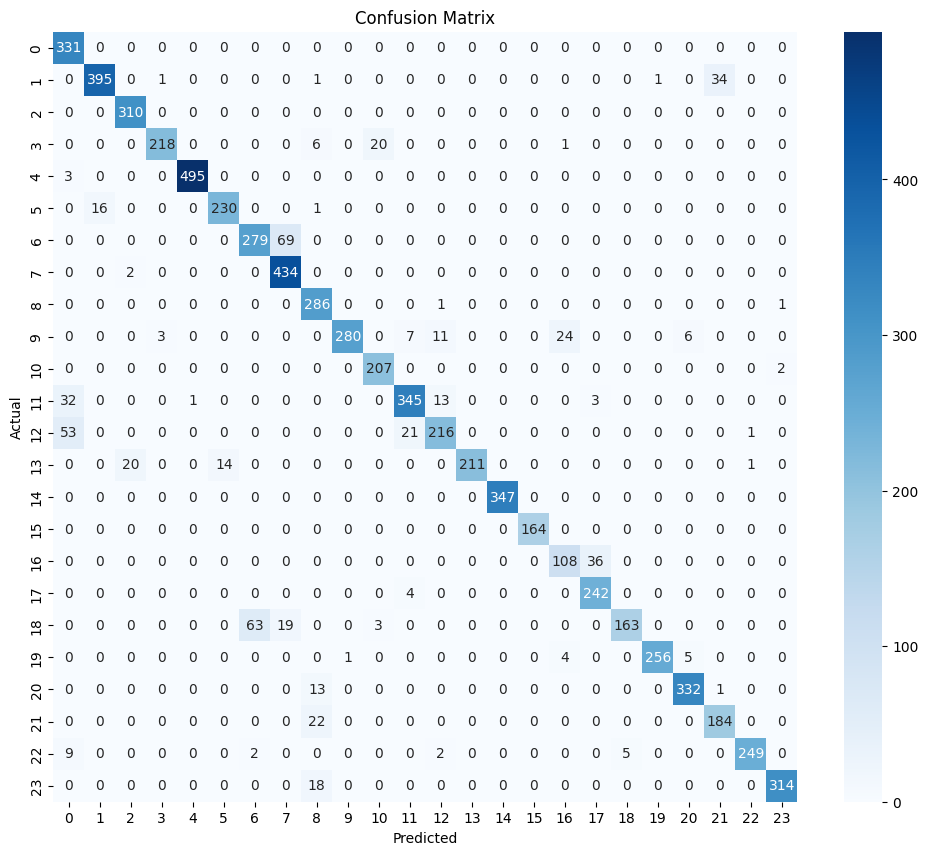

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Classes present in test set: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
Skipping Class 9 (not present in test set)


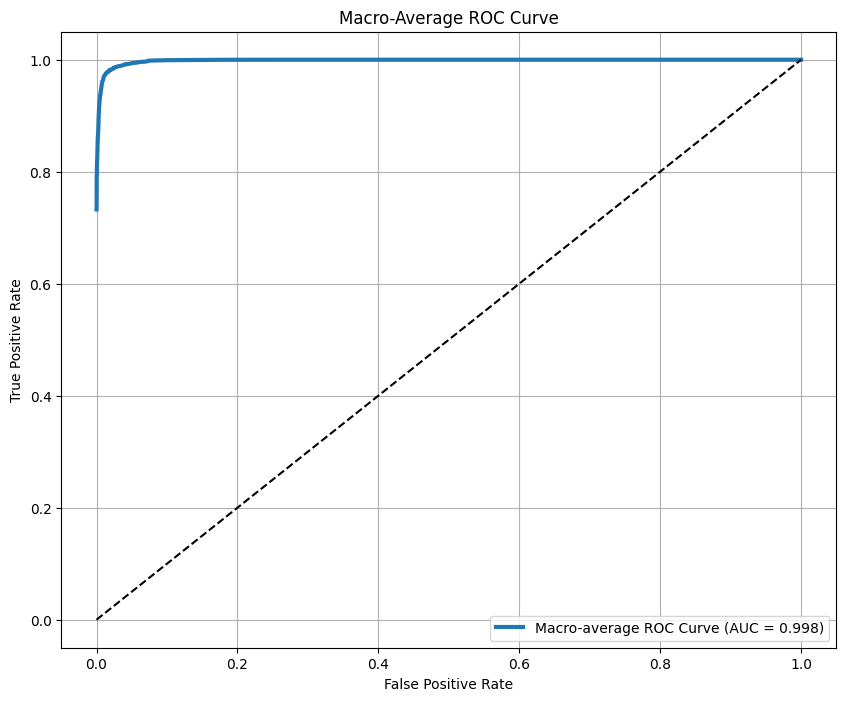

In [ ]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_test_int = np.argmax(y_test, axis=1)


print("Classes present in test set:", np.unique(y_test_int))

y_test_bin = label_binarize(y_test_int, classes=range(25))
y_score = model.predict(X_test)

n_classes = y_test_bin.shape[1]


fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):


    if len(np.unique(y_test_bin[:, i])) < 2:
        print(f"Skipping Class {i} (not present in test set)")
        continue

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


all_fpr = np.unique(np.concatenate([fpr[i] for i in fpr]))


mean_tpr = np.zeros_like(all_fpr)
for i in fpr:
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(fpr)
macro_auc = auc(all_fpr, mean_tpr)


plt.figure(figsize=(10, 8))
plt.plot(all_fpr, mean_tpr, linewidth=3,
         label=f"Macro-average ROC Curve (AUC = {macro_auc:.3f})")


plt.plot([0, 1], [0, 1], 'k--')

plt.title("Macro-Average ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


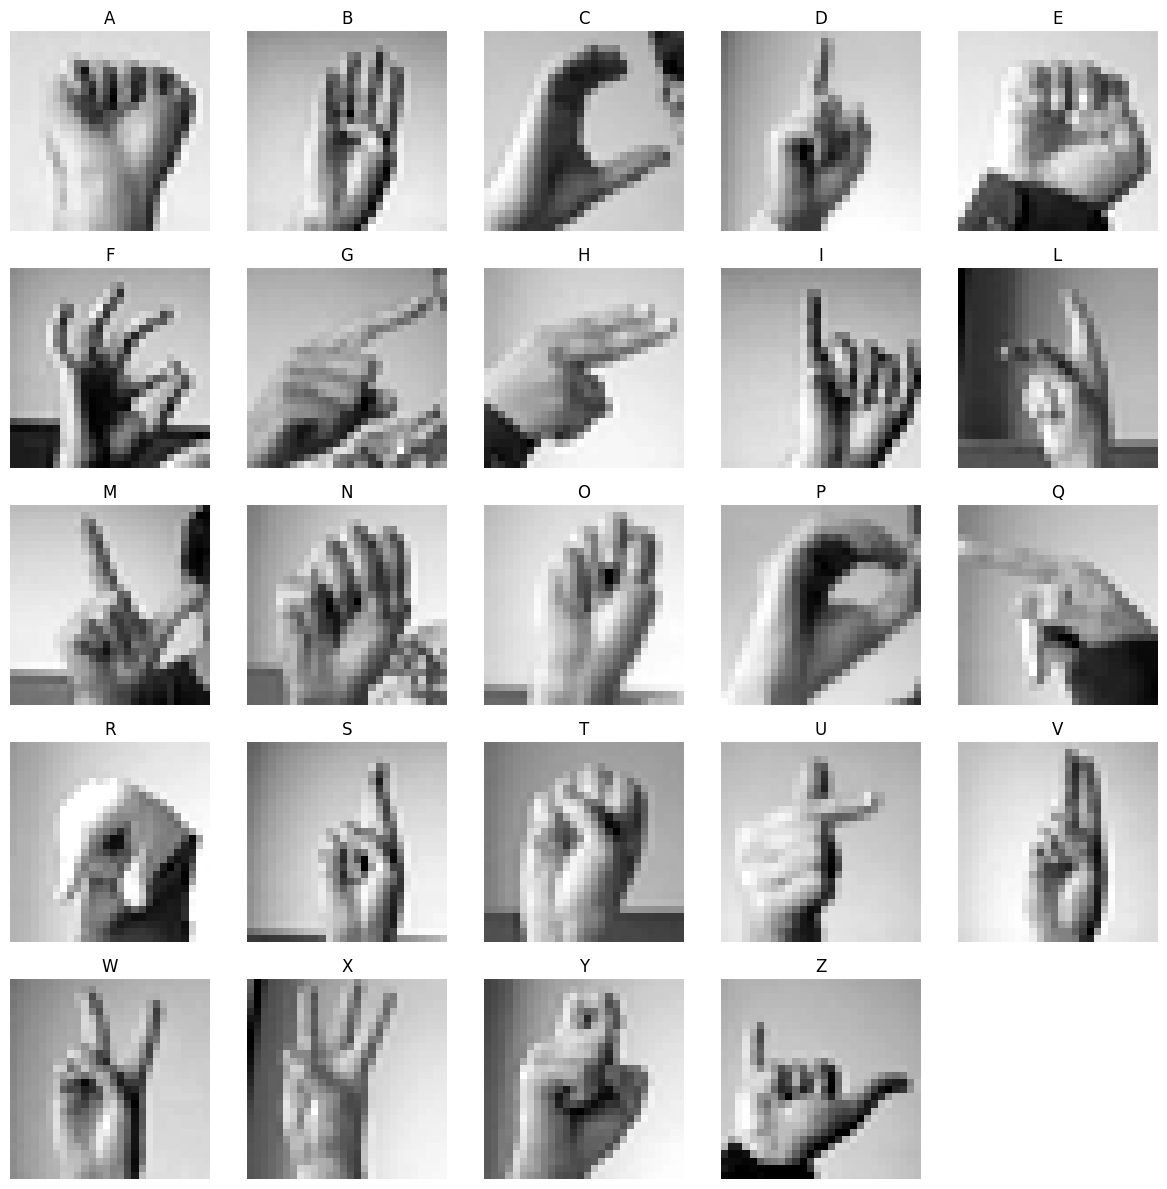

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

label_to_letter = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I',
    9:'K', 10:'L', 11:'M', 12:'N', 13:'O', 14:'P', 15:'Q', 16:'R',
    17:'S', 18:'T', 19:'U', 20:'V', 21:'W', 22:'X', 23:'Y', 24:'Z'
}

available_labels = sorted(train_df["label"].unique())

plt.figure(figsize=(12, 12))

for i, lbl in enumerate(available_labels):
    idx = train_df[train_df["label"] == lbl].index[0]
    image = train_df.drop("label", axis=1).iloc[idx].values.reshape(28, 28)

    plt.subplot(5, 5, i+1)
    plt.imshow(image, cmap="gray")
    plt.title(label_to_letter[lbl])
    plt.axis("off")

plt.tight_layout()
plt.show()
